# Milestone 1 (Mushroom Project)

## Scope
Milestone 1 requirements:
1. Preprocessing techniques
2. Outlier detection
3. Data assessment and visualization for variable relationships

### Notebook Focus
Final cleaned dataset preparation and model-ready classification preprocessing.

## 1) Environment Setup and Imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

def resolve_dataset_path():
    candidates = [
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Could not find 'Mushroom Dataset/mushrooms 2.csv'.")

def _load_base_data():
    df_raw = pd.read_csv(resolve_dataset_path())
    df = df_raw.replace('?', np.nan).drop_duplicates().copy()
    for col in df.columns:
        if df[col].isna().any():
            mode_vals = df[col].mode(dropna=True)
            fill_value = mode_vals.iloc[0] if not mode_vals.empty else 'missing'
            df[col] = df[col].fillna(fill_value)
    return df_raw, df

def preprocess_for_classification_model(remove_outliers=True, rare_ratio=0.01):
    df_raw, df = _load_base_data()
    threshold = max(1, int(len(df) * rare_ratio))
    outlier_mask = pd.Series(False, index=df.index)
    outlier_cols = []

    for col in df.columns:
        if col == 'class':
            continue
        counts = df[col].value_counts(dropna=False)
        rare_values = counts[counts < threshold].index
        if len(rare_values) > 0:
            col_mask = df[col].isin(rare_values)
            outlier_mask = outlier_mask | col_mask
            outlier_cols.append(col)

    df['is_outlier'] = outlier_mask.astype(int)
    if remove_outliers:
        df_model = df[df['is_outlier'] == 0].drop(columns=['is_outlier']).copy()
    else:
        df_model = df.drop(columns=['is_outlier']).copy()

    y = df_model['class'].map({'e': 0, 'p': 1}).astype(int)
    X = df_model.drop(columns=['class'])
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_encoded = encoder.fit_transform(X)

    print('Raw shape:', df_raw.shape)
    print('Shape after cleaning:', df.shape)
    print('Shape used for model:', df_model.shape)
    print('Columns with rare-category outliers:', outlier_cols)

    plt.figure(figsize=(5, 3))
    sns.countplot(x=df_model['class'], hue=df_model['class'], palette='Set2', legend=False)
    plt.title('Class Distribution After Preprocessing')
    plt.tight_layout()
    plt.show()

    return df_model, X_encoded, y, encoder, outlier_cols

# Mushroom Phase Final Clean Workflow

This notebook is a clean, reproducible version of the full mushroom workflow:
1. Data understanding
2. Categorical-safe preprocessing
3. Outlier detection and handling
4. Classification comparison
5. Clustering comparison
6. Association mining
7. Final model leaderboard

In [4]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, silhouette_score, adjusted_rand_score
)
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

try:
    from sklearn_extra.cluster import KMedoids
    HAS_KMEDOIDS = True
except ModuleNotFoundError:
    HAS_KMEDOIDS = False

HAS_APYORI = importlib.util.find_spec('apyori') is not None
HAS_PYFPGROWTH = importlib.util.find_spec('pyfpgrowth') is not None
HAS_PYECLAT = importlib.util.find_spec('pyECLAT') is not None

if HAS_APYORI:
    from apyori import apriori
if HAS_PYFPGROWTH:
    import pyfpgrowth
if HAS_PYECLAT:
    from pyECLAT import ECLAT

print('KMedoids:', HAS_KMEDOIDS, '| Apriori:', HAS_APYORI, '| FP-Growth:', HAS_PYFPGROWTH, '| ECLAT:', HAS_PYECLAT)

KMedoids: False | Apriori: True | FP-Growth: True | ECLAT: True


In [5]:
def resolve_mushroom_csv():
    candidates = [
        Path.cwd() / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent.parent / 'Mushroom Dataset' / 'mushrooms 2.csv',
        Path.cwd().parent / 'project B' / 'mushrooms 1.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Mushroom csv file was not found from current notebook location.')

csv_path = resolve_mushroom_csv()
df_raw = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
print('Shape:', df_raw.shape)
display(df_raw.head(3))

Loaded from: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\Mushroom Classifier\Mushroom Dataset\mushrooms 2.csv
Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


## 1) Data Audit and Cleaning

In [6]:
df = df_raw.copy()
df = df.replace('?', np.nan)

before = len(df)
df = df.drop_duplicates().copy()
print('Dropped duplicates:', before - len(df))

print('Missing values before fill:')
display(df.isna().sum().sort_values(ascending=False).head(10))

for c in df.columns:
    if df[c].isna().any():
        if pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].fillna(df[c].mean())
        else:
            mode_vals = df[c].mode(dropna=True)
            df[c] = df[c].fillna(mode_vals.iloc[0] if not mode_vals.empty else 'missing')

single_cols = [c for c in df.columns if df[c].nunique() <= 1]
if single_cols:
    df = df.drop(columns=single_cols)

print('Dropped single-value columns:', single_cols)
print('Missing values after fill:', int(df.isna().sum().sum()))

Dropped duplicates: 0
Missing values before fill:


stalk-root                  2480
stalk-surface-above-ring       0
population                     0
spore-print-color              0
ring-type                      0
ring-number                    0
veil-color                     0
veil-type                      0
stalk-color-below-ring         0
stalk-color-above-ring         0
dtype: int64

Dropped single-value columns: ['veil-type']
Missing values after fill: 0


## 2) Rare-Category Outliers

Outlier rows by rare-category rule: 473
Columns with rare categories: ['cap-shape', 'cap-surface', 'cap-color', 'odor', 'gill-color', 'stalk-surface-above-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color']


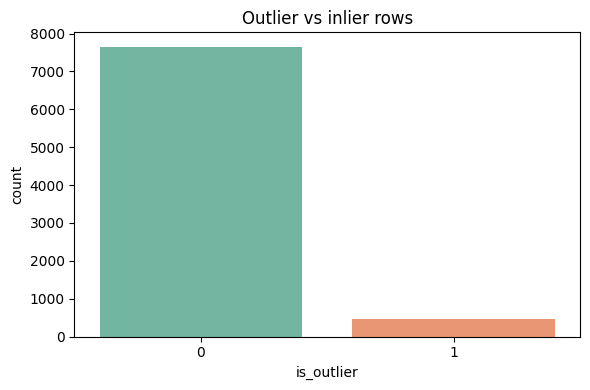

Rows after dropping outliers: 7651


In [ ]:
threshold_ratio = 0.01
min_count = max(1, int(threshold_ratio * len(df)))

outlier_mask = pd.Series(False, index=df.index)
rare_by_col = {}
for col in df.columns:
    if col == 'class':
        continue
    counts = df[col].value_counts(dropna=False)
    rare_vals = counts[counts < min_count].index.tolist()
    if rare_vals:
        rare_by_col[col] = rare_vals
        outlier_mask = outlier_mask | df[col].isin(rare_vals)

df['is_outlier'] = outlier_mask.astype(int)
print('Outlier rows by rare-category rule:', int(df['is_outlier'].sum()))
print('Columns with rare categories:', list(rare_by_col.keys()))

plt.figure(figsize=(6, 4))
sns.countplot(x='is_outlier', data=df, hue='is_outlier', palette='Set2', legend=False)
plt.title('Outlier vs inlier rows')
plt.tight_layout()
plt.show()

df_grouped = df.copy()
for col, vals in rare_by_col.items():
    df_grouped[col] = df_grouped[col].replace(vals, 'Other')

df_dropped = df[df['is_outlier'] == 0].drop(columns=['is_outlier']).copy()
print('Rows after dropping outliers:', len(df_dropped))

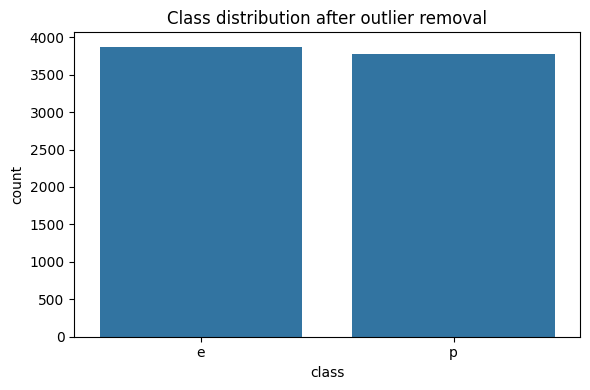

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_dropped, order=df_dropped['class'].value_counts().index)
plt.title('Class distribution after outlier removal')
plt.tight_layout()
plt.show()

## 3) Modeling Data Preparation

In [9]:
DATA_VARIANT = 'drop_outliers'  # options: drop_outliers, grouped_other

if DATA_VARIANT == 'grouped_other':
    df_model = df_grouped.drop(columns=['is_outlier']).copy()
else:
    df_model = df_dropped.copy()

y = df_model['class'].map({'e': 0, 'p': 1}).astype(int)
X = df_model.drop(columns=['class'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train = ohe.fit_transform(X_train_raw)
X_test = ohe.transform(X_test_raw)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train/Test sizes:', X_train.shape, X_test.shape)

Train/Test sizes: (6120, 92) (1531, 92)


In [ ]:
from scipy.stats import chi2_contingency, entropy

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))

def theils_u(x, y):
    x_values = pd.Series(x).astype('category')
    y_values = pd.Series(y).astype('category')
    x_entropy = entropy(x_values.value_counts(normalize=True), base=2)
    if x_entropy == 0:
        return 1.0
    conditional_entropies = []
    for y_cat in y_values.cat.categories:
        x_given_y = x_values[y_values == y_cat]
        if len(x_given_y) == 0:
            continue
        probs = x_given_y.value_counts(normalize=True)
        conditional_entropies.append((len(x_given_y) / len(x_values)) * entropy(probs, base=2))
    return max(0, (x_entropy - sum(conditional_entropies)) / x_entropy)

categorical_cols = [c for c in df_model.columns if c != 'class']
cramers_df = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)
theils_df = pd.DataFrame(index=categorical_cols, columns=categorical_cols, dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_df.loc[col1, col2] = cramers_v(df_model[col1], df_model[col2])
        theils_df.loc[col1, col2] = theils_u(df_model[col1], df_model[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_df, cmap='YlGnBu', square=True)
plt.title("Cramér's V Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(theils_df, cmap='coolwarm', square=True)
plt.title("Theil's U Correlation Matrix")
plt.tight_layout()
plt.show()

top_pairs = []
for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j:
            top_pairs.append((col1, col2, cramers_df.loc[col1, col2], theils_df.loc[col1, col2]))

top_pairs_df = pd.DataFrame(top_pairs, columns=['feature_1', 'feature_2', 'cramers_v', 'theils_u'])
display(top_pairs_df.sort_values('cramers_v', ascending=False).head(10))

## 3.1) Categorical Correlation Analysis

This section adds Cramér's V and Theil's U from the Project B notebooks to measure relationships among categorical features.

## 4) Classification Comparison

In [10]:
classification_models = {
    'Dummy': DummyClassifier(strategy='most_frequent', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Bernoulli NB': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=2500, random_state=42),
    'KNN Euclidean': KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    'KNN Manhattan': KNeighborsClassifier(n_neighbors=7, metric='manhattan'),
    'SVM RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

rows = []
trained = {}
for name, model in classification_models.items():
    use_scaled = name in ['Logistic Regression', 'KNN Euclidean', 'KNN Manhattan', 'SVM RBF']
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    })
    trained[name] = model

results_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.iloc[0]['model']
best_model = trained[best_name]
best_scaled = best_name in ['Logistic Regression', 'KNN Euclidean', 'KNN Manhattan', 'SVM RBF']
best_Xte = X_test_scaled if best_scaled else X_test
best_pred = best_model.predict(best_Xte)

print('Best model:', best_name)
print(classification_report(y_test, best_pred, target_names=['edible', 'poisonous']))

,model,accuracy,precision,recall,f1
0,Decision Tree,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Gradient Boosting,1.000000,1.000000,1.000000,1.000000
3,Logistic Regression,0.998694,1.000000,0.997354,0.998675
4,KNN Euclidean,0.998694,1.000000,0.997354,0.998675
5,KNN Manhattan,0.998694,1.000000,0.997354,0.998675
6,SVM RBF,0.998694,1.000000,0.997354,0.998675
7,Bernoulli NB,0.954278,0.992816,0.914021,0.951791
8,Dummy,0.506205,0.000000,0.000000,0.000000


Best model: Decision Tree
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       775
   poisonous       1.00      1.00      1.00       756

    accuracy                           1.00      1531
   macro avg       1.00      1.00      1.00      1531
weighted avg       1.00      1.00      1.00      1531



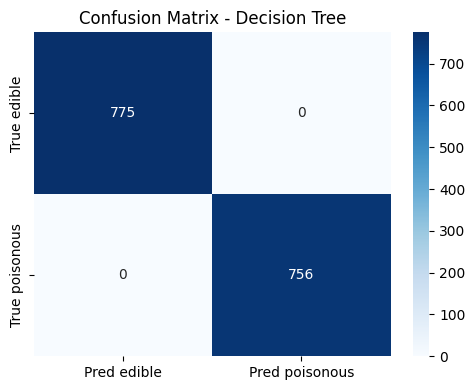

In [11]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred edible', 'Pred poisonous'], yticklabels=['True edible', 'True poisonous'])
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

## 5) Clustering Comparison

In [12]:
cluster_rows = []

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)
cluster_rows.append({
    'method': 'KMeans',
    'silhouette_train': silhouette_score(X_train_scaled, kmeans_labels),
    'ari_test_vs_class': adjusted_rand_score(y_test, kmeans.predict(X_test_scaled))
})

if HAS_KMEDOIDS:
    kmed = KMedoids(n_clusters=2, metric='manhattan', random_state=42)
    kmed_labels = kmed.fit_predict(X_train_scaled)
    cluster_rows.append({
        'method': 'KMedoids',
        'silhouette_train': silhouette_score(X_train_scaled, kmed_labels),
        'ari_test_vs_class': adjusted_rand_score(y_test, kmed.predict(X_test_scaled))
    })

db = DBSCAN(eps=0.35, min_samples=10, metric='euclidean')
db_labels = db.fit_predict(X_train_scaled)
valid = db_labels != -1
db_sil = np.nan
if valid.sum() > 1 and len(np.unique(db_labels[valid])) > 1:
    db_sil = silhouette_score(X_train_scaled[valid], db_labels[valid])
cluster_rows.append({
    'method': 'DBSCAN',
    'silhouette_train': db_sil,
    'ari_test_vs_class': np.nan
})

cluster_df = pd.DataFrame(cluster_rows)
display(cluster_df)

,method,silhouette_train,ari_test_vs_class
0,KMeans,0.172653,0.631641
1,DBSCAN,NaN,NaN


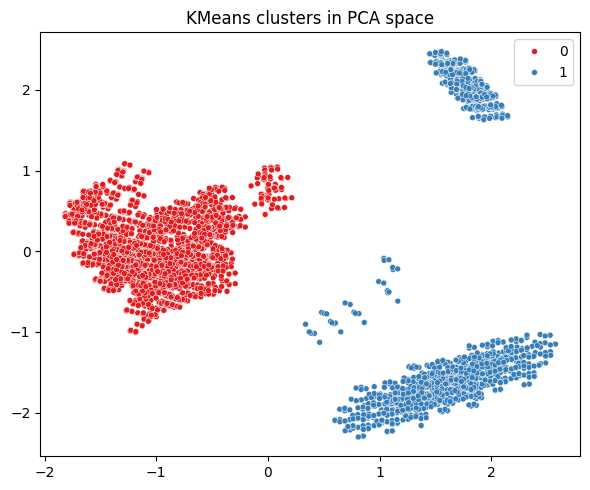

In [13]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=kmeans_labels, palette='Set1', s=18)
plt.title('KMeans clusters in PCA space')
plt.tight_layout()
plt.show()

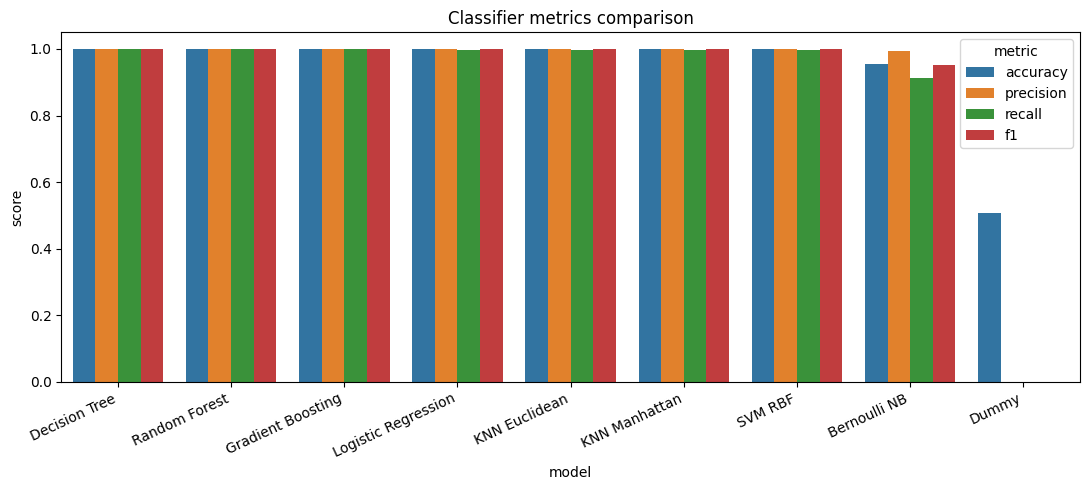

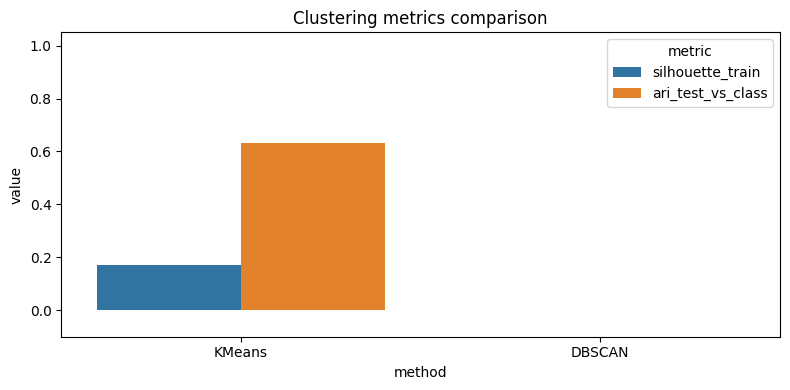

In [14]:
plot_df = results_df.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'f1'],
    var_name='metric',
    value_name='score'
 )

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='model', y='score', hue='metric')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.title('Classifier metrics comparison')
plt.tight_layout()
plt.show()

cluster_plot = cluster_df.copy()
for c in ['silhouette_train', 'ari_test_vs_class']:
    cluster_plot[c] = pd.to_numeric(cluster_plot[c], errors='coerce')

cluster_plot_long = cluster_plot.melt(
    id_vars='method',
    value_vars=['silhouette_train', 'ari_test_vs_class'],
    var_name='metric',
    value_name='value'
 )

plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_plot_long, x='method', y='value', hue='metric')
plt.ylim(-0.1, 1.05)
plt.title('Clustering metrics comparison')
plt.tight_layout()
plt.show()

## 5.1) Combined Comparison Views (Merged from master_comparison)

This section gives compact visual summaries of classifier and clustering results in one place.

## 6) Frequent Itemsets and Rules

In [15]:
transactions = X_train_raw.astype(str).apply(lambda r: [f'{c}={v}' for c, v in r.items()], axis=1).tolist()
print('Original transactions:', len(transactions))

# Runtime controls for association mining (faster on large data).
ASSOC_MAX_TRANSACTIONS = 3000
ASSOC_MIN_SUPPORT = 0.3
ASSOC_MIN_CONFIDENCE = 0.8
ASSOC_MAX_RULE_LENGTH = 3
ASSOC_RANDOM_STATE = 42

if len(transactions) > ASSOC_MAX_TRANSACTIONS:
    rng = np.random.default_rng(ASSOC_RANDOM_STATE)
    idx = rng.choice(len(transactions), size=ASSOC_MAX_TRANSACTIONS, replace=False)
    assoc_transactions = [transactions[i] for i in idx]
else:
    assoc_transactions = transactions

print('Mining transactions used:', len(assoc_transactions))

if HAS_APYORI:
    ap_rules = list(
        apriori(
            assoc_transactions,
            min_support=ASSOC_MIN_SUPPORT,
            min_confidence=ASSOC_MIN_CONFIDENCE,
            min_lift=1.0,
            min_length=2,
            max_length=ASSOC_MAX_RULE_LENGTH
        )
    )
    print('Apriori rules:', len(ap_rules))
else:
    print('Apriori not available')

if HAS_PYFPGROWTH:
    patterns = pyfpgrowth.find_frequent_patterns(assoc_transactions, int(ASSOC_MIN_SUPPORT * len(assoc_transactions)))
    fp_rules = pyfpgrowth.generate_association_rules(patterns, ASSOC_MIN_CONFIDENCE)
    print('FP-Growth patterns:', len(patterns), '| rules:', len(fp_rules))
else:
    print('FP-Growth not available')

if HAS_PYECLAT:
    eclat_df = pd.DataFrame(assoc_transactions)
    ecl = ECLAT(data=eclat_df, verbose=False)
    _, supports = ecl.fit(min_support=ASSOC_MIN_SUPPORT, min_combination=2, max_combination=ASSOC_MAX_RULE_LENGTH, separator=' & ')
    print('ECLAT itemsets:', len(supports))
else:
    print('ECLAT not available')

Original transactions: 6120
Mining transactions used: 3000
Apriori rules: 325
FP-Growth patterns: 1198 | rules: 1140
Combination 2 by 2


276it [00:06, 44.98it/s]


Combination 3 by 3


2024it [00:36, 56.18it/s]

ECLAT itemsets: 445


## 7) Final Output

In [ ]:
print('Best classifier based on F1:', results_df.iloc[0]['model'])
print('Top 3 classifiers:')
display(results_df.head(3))
print('Clustering summary:')
display(cluster_df)

Best classifier based on F1: Decision Tree
Top 3 classifiers:


,model,accuracy,precision,recall,f1
0,Decision Tree,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0


Clustering summary:


,method,silhouette_train,ari_test_vs_class
0,KMeans,0.172653,0.631641
1,DBSCAN,NaN,NaN
